# Fitting DMD Models of Many Flavors, and SINDy models to Simulated Circuit Data

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
from pydmd import DMD
from pydmd import DMDc
from pydmd import FbDMD
from pydmd import OptDMD
from scipy.io import loadmat,savemat
from scipy.signal import StateSpace, lsim, dlsim, cont2discrete,butter,filtfilt,dimpulse,impulse,dlti
import pickle 
import sys
import functions
from functions.compare_operators import compare_operators
from functions.make_graph import make_graph
from sklearn.metrics import mean_squared_error


In [39]:
filename = 'C:/Users/ducks/Plasma-Shit/Python_Stuff/data/continuous_vacuum_ss_model' #Vacuum state space model
with open(filename,'rb') as file:
    sysc = pickle.load(file)
    print(f'object successfully saved to {filename}')
A = sysc.A #A, B, C, and D matrix from the continuous time vacuum model
B = sysc.B
C = sysc.C
D = sysc.D

SampleTime = 1e-6
sysd = cont2discrete((A,B,C,D),SampleTime,'zoh') #discrete time version of the vacuum system

#A,B,C,D discrete time versions

A_d = sysd[0]
B_d = sysd[1]
C_d = sysd[2]
D_d = sysd[3]

time = np.linspace(0,.004,int(np.ceil(.004/SampleTime)))

#need to load in some voltage supply inputs for our system
Amplitude = 500
voltage = Amplitude*np.sin(2*np.pi*19000*time)
voltage_stack = np.vstack((voltage,voltage,voltage,voltage))


print(np.shape(time))

object successfully saved to C:/Users/ducks/Plasma-Shit/Python_Stuff/data/continuous_vacuum_ss_model
(4001,)


Text(0.5, 1.0, 'Eigenvalues of Discrete Time A matrix')

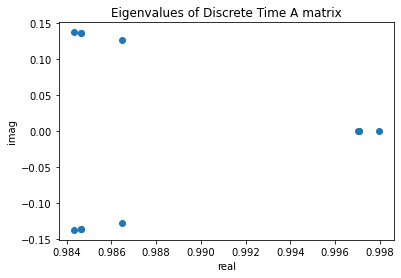

In [40]:
#check that eigevnalues are correct

eigs_discrete = np.linalg.eigvals(A_d)

plt.figure()
plt.scatter(eigs_discrete.real,eigs_discrete.imag)
plt.xlabel('real')
plt.ylabel('imag')
plt.title('Eigenvalues of Discrete Time A matrix')



# Let's simulate some data

In [41]:
noise_power = 10

xout_discrete = dlsim((sysd),voltage_stack.T,time)[-1]
print(np.shape(xout_discrete))

#We are going to add 1 percent noise to our data to see how our methods fair
rmse = mean_squared_error(xout_discrete[:, 1], np.zeros(xout_discrete[:, 1].shape), squared=False)
xout_discrete = xout_discrete + np.random.normal(0, rmse / 100.0 * noise_power, xout_discrete.shape)  # add noise_power amount of noise


(4001, 12)


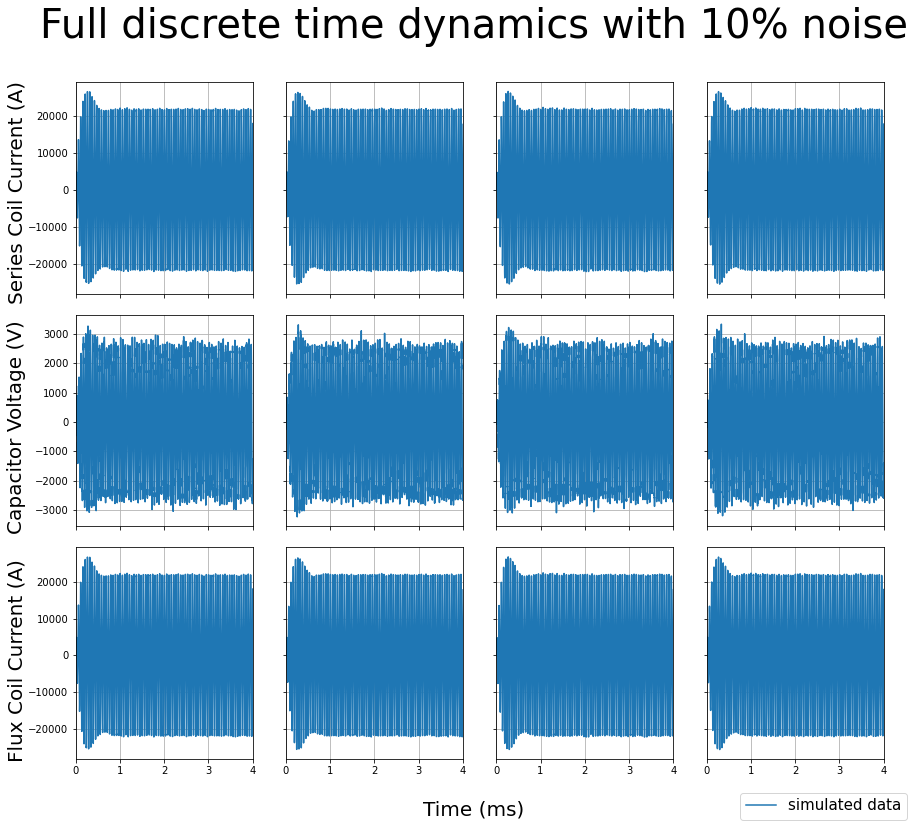

In [42]:
make_graph(data = [xout_discrete],title = f'Full discrete time dynamics with {noise_power}% noise',legend = ['simulated data'],impulse = False,time = time)

# Now we would like to train Various Models (DMD, SINDy), and track the residual as a function of time

In [43]:
#Because standard DMD methods don't play nice with actuation, we're going to train the DMD models on mock impulse response

impulse_input = np.zeros(np.shape(voltage_stack))

impulse_input[0,0] = 1

t,y,xout_discrete_impulse = dlsim(sysd,impulse_input.T,time) #impulse response

rmse_impulse = mean_squared_error(xout_discrete_impulse[:, 1], np.zeros(xout_discrete_impulse[:, 1].shape), squared=False)
xout_discrete_impulse = xout_discrete_impulse + np.random.normal(0, rmse_impulse / 100.0 * noise_power, xout_discrete_impulse.shape)  # add noise_power amount of noise

xout_discrete_impulse = xout_discrete_impulse.T

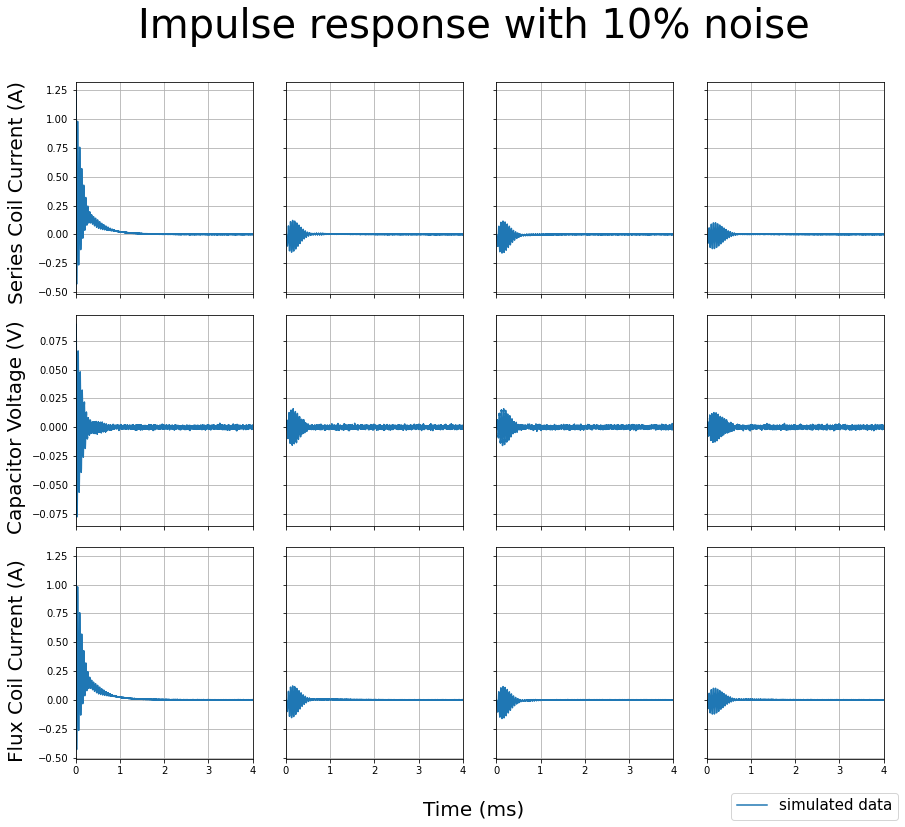

In [44]:
make_graph(data = [xout_discrete_impulse.T],title = f'Impulse response with {noise_power}% noise',legend = ['simulated data'],impulse = False,time = time)

In [45]:
 #full rank fit to the data

# dmd = DMD(svd_rank = -1, exact= True)

# dmd.fit(xout_discrete_impulse)

# A_dmd = dmd.operator._Atilde


In [46]:
A_dmd = xout_discrete_impulse[:,1::]@np.linalg.pinv(xout_discrete_impulse[:,:-1])
print(np.shape(A_dmd))

(12, 12)


Text(0.5, 1.0, 'Eigenvalues of DMD compared to ground truth with 10% noise')

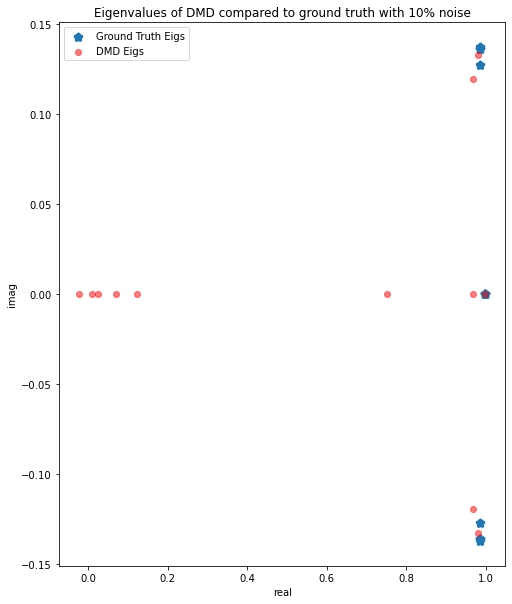

In [47]:
#check that eigevnalues are correct

eigs_discrete = np.linalg.eigvals(A_d)

plt.figure(figsize  = (8,10))
plt.scatter(eigs_discrete.real,eigs_discrete.imag,marker = "*",linewidths = 4)
plt.scatter(np.linalg.eigvals(A_dmd).real,np.linalg.eigvals(A_dmd).imag,alpha = .5,color = 'r')
plt.legend(['Ground Truth Eigs','DMD Eigs'])
plt.xlabel('real')
plt.ylabel('imag')
plt.title(f'Eigenvalues of DMD compared to ground truth with {noise_power}% noise')



# Takeaway: With moderate noise added to the training data, the eigenvalues of exact dmd are pulled into the left half plane.

# Let's do a SINDy model as well


In [48]:
library = ps.PolynomialLibrary(degree=1,include_bias=False)
optimizer = ps.STLSQ(threshold=0)
model = ps.SINDy(feature_library = library,discrete_time=True,optimizer= optimizer)
model.fit(xout_discrete_impulse.T,time) 

A_SINDy = model.coefficients()

print(np.shape(A_SINDy))

(12, 12)


c:\Users\ducks\anaconda3\lib\site-packages\matplotlib\collections.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


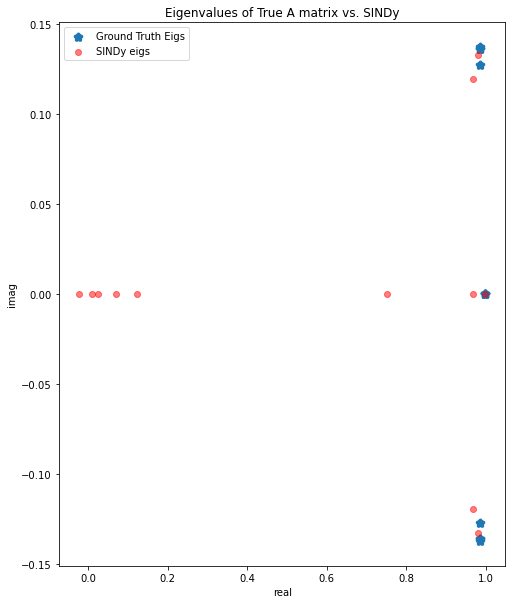

In [49]:
plt.figure(figsize  = (8,10))
plt.scatter(eigs_discrete,eigs_discrete.imag,marker = "*",linewidths = 4)
plt.scatter(np.linalg.eigvals(A_SINDy).real,np.linalg.eigvals(A_SINDy).imag,alpha = .5,color = 'r')
plt.legend(['Ground Truth Eigs','SINDy eigs'])
plt.xlabel('real')
plt.ylabel('imag')
plt.title('Eigenvalues of True A matrix vs. SINDy')

plt.rcParams['savefig.facecolor']='white'
plt.savefig(f'DMD eigs vs ground truth eigs {noise_power}% noise',bbox_inches="tight")

# SINDy with zero thresholding just reduces to exact DMD. Can add thresholding to tweak this

## The final thing we would like to do here is track the rate at which the residual between the simulated DMD matrix diverges from the ground truth data. To do this, we will take the A matrix computed by each operator, and see how well it replicates the training data. We will also pair this matrix with a B matrix to see how well the system can handle a test case where a voltage waveform is given as an input

In [50]:
operator_list = [A_dmd,A_SINDy] #removed FbDMD


trajectory_list = compare_operators(operator_list,(B_d,C_d,D_d),impulse_input,time,SampleTime)

data_list = [trajectory_list[0]] + [xout_discrete_impulse.T]



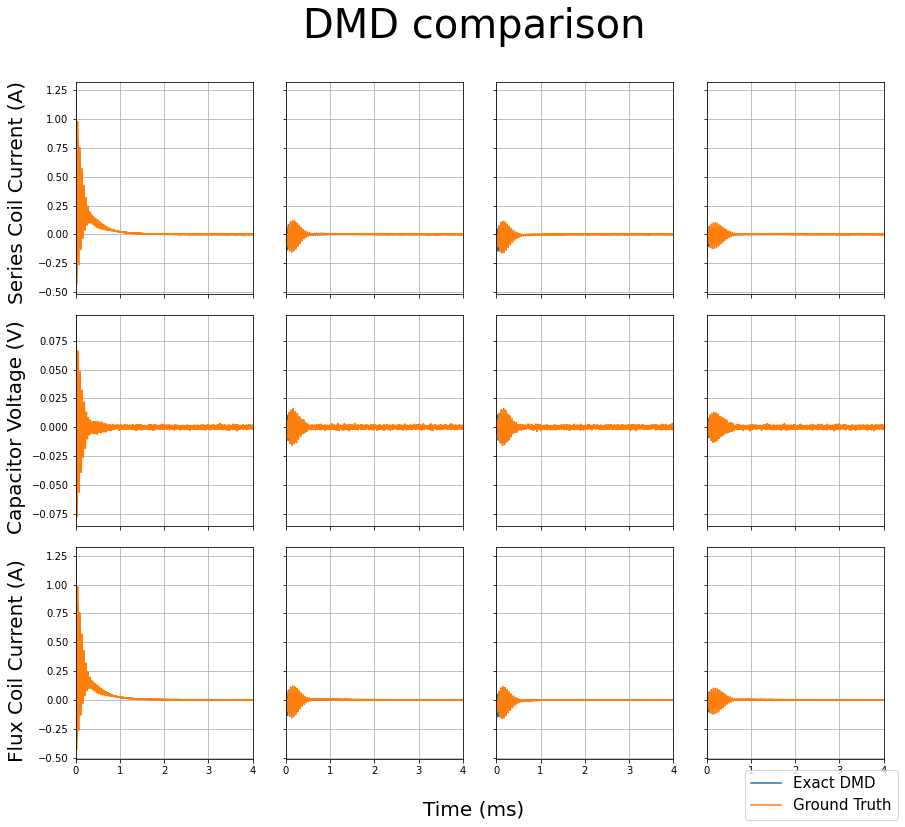

In [51]:
make_graph(data =data_list, title = 'DMD comparison', legend = ['Exact DMD','Ground Truth'], impulse = False, time = time)

# The next thing is to plot the residual  as a function of time in each state

In [52]:
residual_list = []


for trajectory in trajectory_list:
    residual = (trajectory - xout_discrete_impulse.T)**2 #LSTSQ error
    residual_list.append(residual)
print(len(residual_list))

2


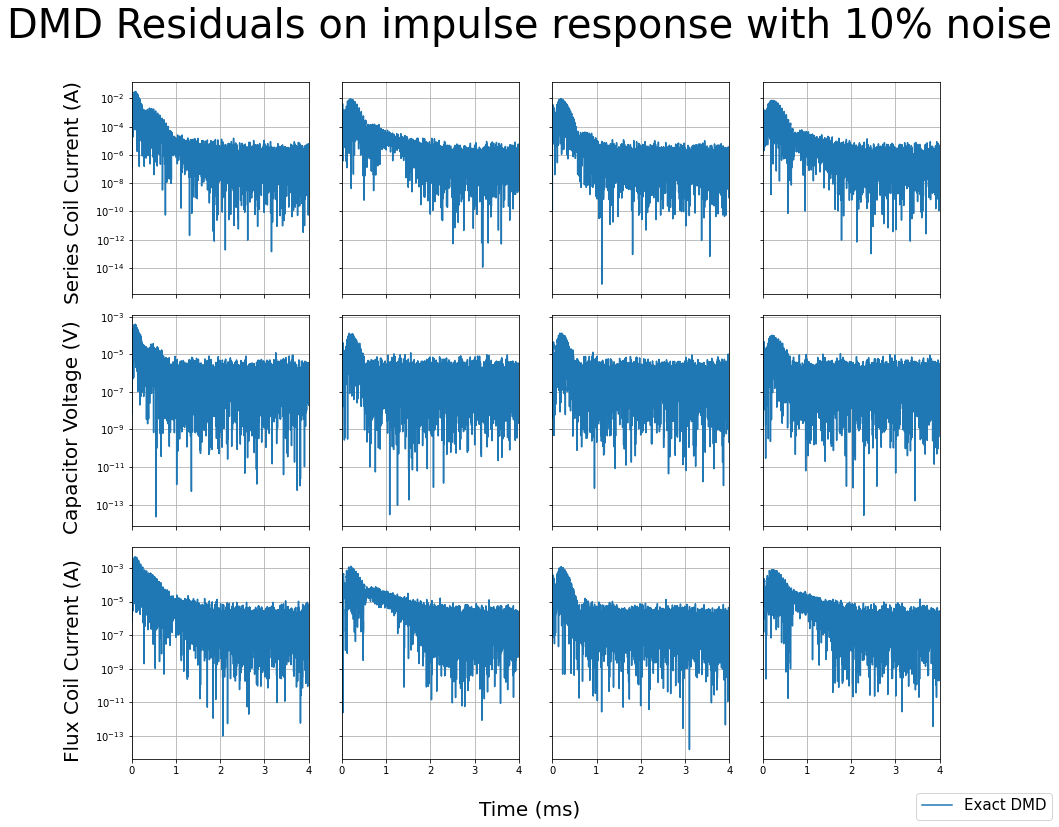

In [53]:
make_graph(data = [residual_list[0]], title = f'DMD Residuals on impulse response with {noise_power}% noise', legend = ['Exact DMD'], impulse = False, time = time, log_scale= True)

plt.rcParams['savefig.facecolor']='white'
plt.savefig(f'DMD residual on impulse response {noise_power}% noise',bbox_inches="tight")

# Simulate DMD and Sindy models with new x0

In [54]:
x0 = 2
trajectory_list_new_x0 = compare_operators(operator_list,(B_d,C_d,D_d),impulse_input,time,SampleTime,x0)

residual_list_new_x0 = []

xout_discrete_impulse_new_x0 = dlsim(sysd,impulse_input.T,time,x0)[-1]
for trajectory in trajectory_list:
    residual = (trajectory - xout_discrete_impulse_new_x0)**2 #LSTSQ error
    residual_list_new_x0.append(residual)
print(len(residual_list_new_x0))

data_list_new_x0 = [trajectory_list_new_x0[0]] + [xout_discrete_impulse_new_x0]
print(len(data_list_new_x0))

2
2


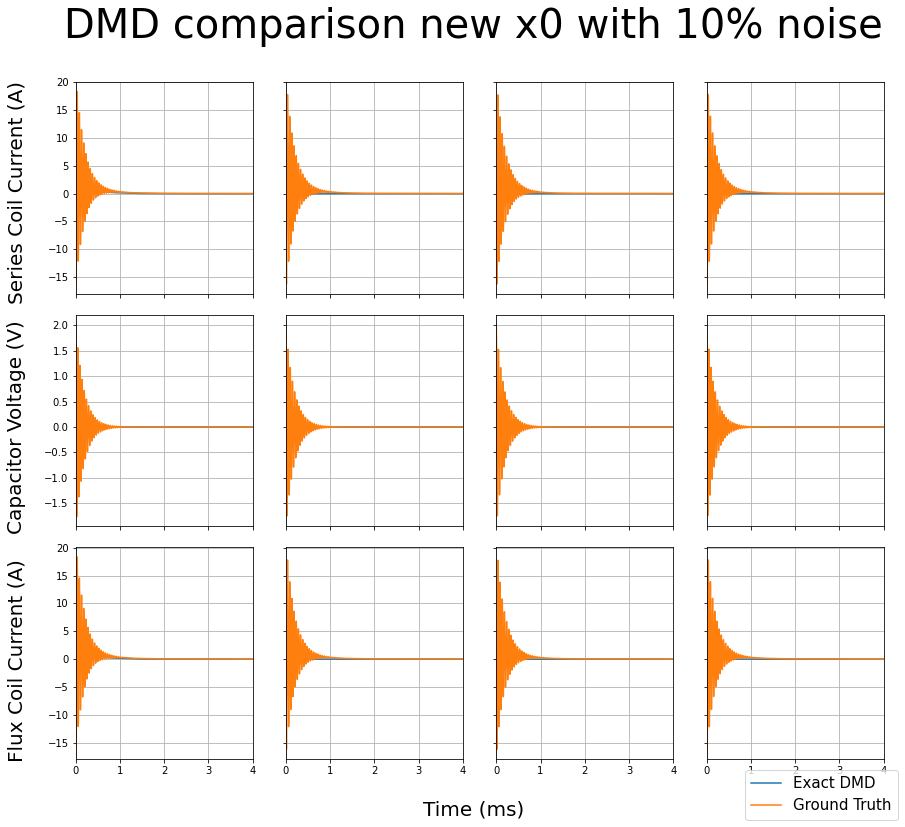

In [55]:
make_graph(data =data_list_new_x0, title = f'DMD comparison new x0 with {noise_power}% noise', legend = ['Exact DMD','Ground Truth'], impulse = False, time = time)

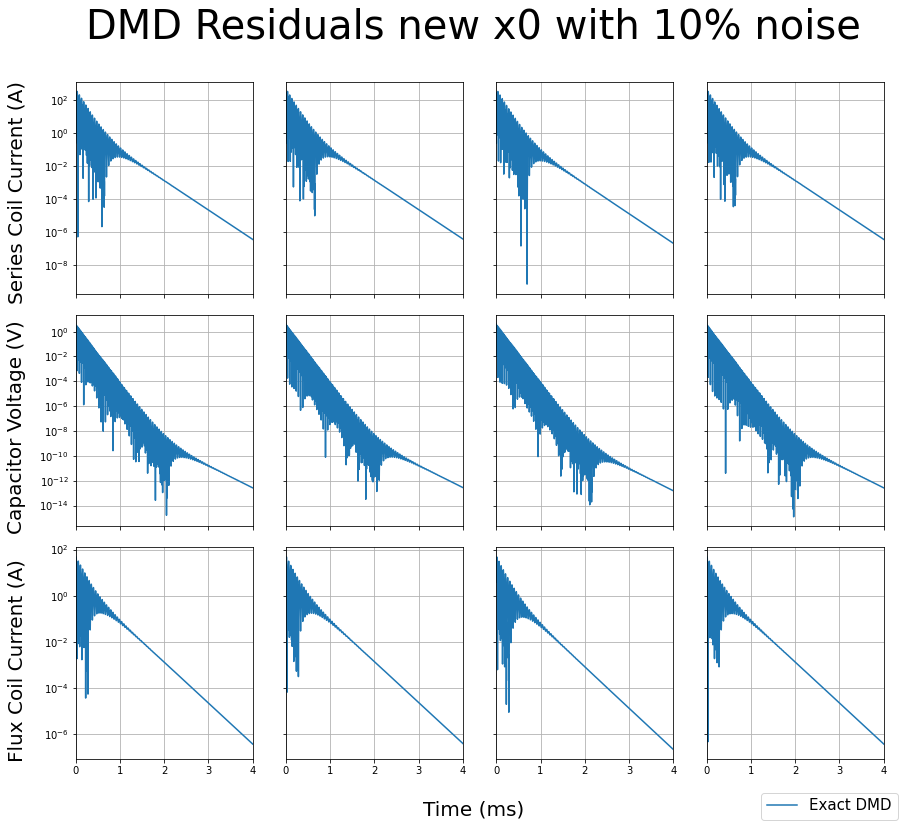

In [56]:
make_graph(data = [residual_list_new_x0[0]], title = f'DMD Residuals new x0 with {noise_power}% noise', legend = ['Exact DMD'], impulse = False, time = time, log_scale= True)
plt.rcParams['savefig.facecolor']='white'
plt.savefig(f'DMD residual new x0 {noise_power}% noise',bbox_inches="tight")

# Let's simulate these DMD models on a full SPA waveform

In [57]:
print(np.shape(voltage_stack))

(4, 4001)


In [58]:
test_trajectory_list = compare_operators(operator_list,(B_d,C_d,D_d),voltage_stack,time,SampleTime)
data_list_test = []
data_list_test.append(xout_discrete)
data_list_test.append(test_trajectory_list[0])



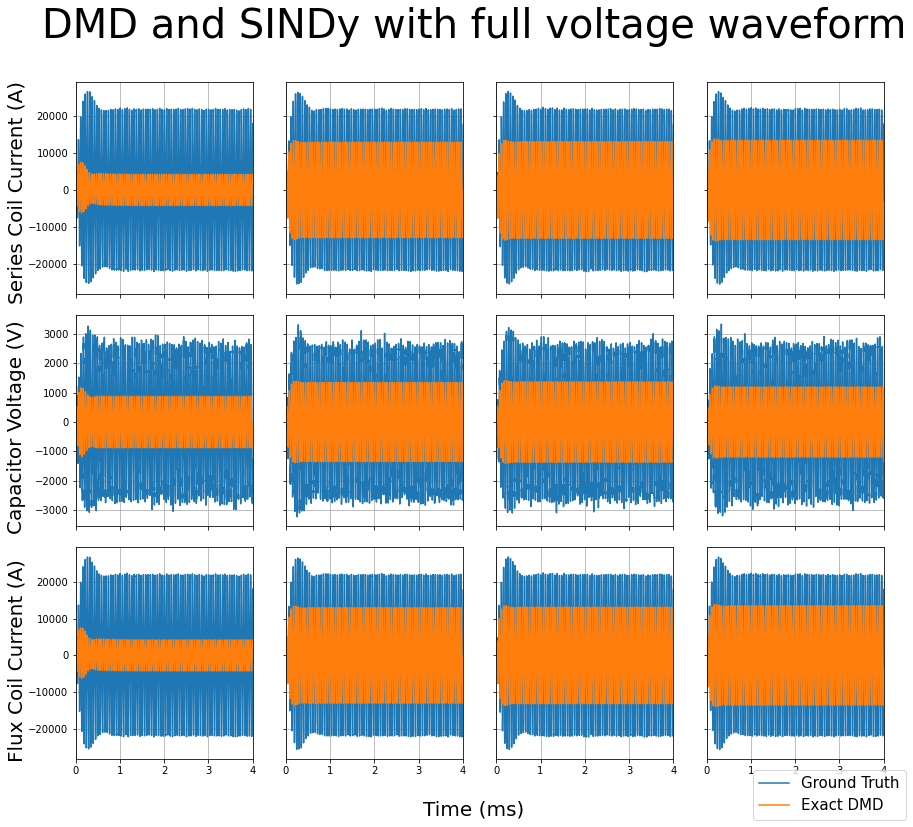

In [59]:
make_graph(data = data_list_test, title = 'DMD and SINDy with full voltage waveform', legend = ['Ground Truth','Exact DMD'], impulse = False, time = time)
plt.rcParams['savefig.facecolor']='white'
plt.savefig(f'DMD vs test case {noise_power}% noise',bbox_inches="tight")

In [60]:
test_residual_list = []


for trajectory in test_trajectory_list:
    residual = (trajectory - xout_discrete)**2 #LSTSQ error
    test_residual_list.append(residual)


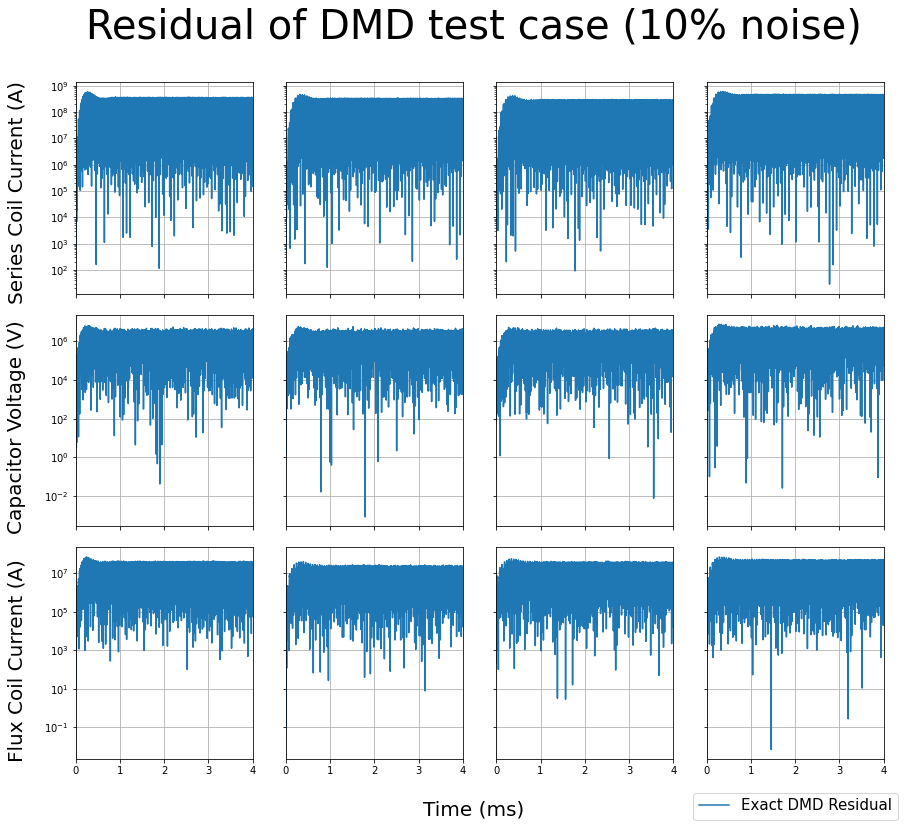

In [61]:
make_graph(data = [test_residual_list[0]], title = f'Residual of DMD test case ({noise_power}% noise)', legend = ['Exact DMD Residual'], impulse = False, time = time,log_scale=True)
plt.savefig(f'DMD residual on test case {noise_power}% noise',bbox_inches="tight")

# Also a quick DMDc fit

In [62]:

# voltage_stack = voltage_stack[:,0:-1]
# np.shape(voltage_stack)

In [63]:
# I think I'm just gonna write my own dmdc function...
# dmdc = DMDc(svd_rank = -1)
# dmdc.fit(xout_discrete.T,voltage_stack)

In [64]:
# DMDc_operator = np.shape(dmdc._Atilde)